In [17]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.stats as stats
import statsmodels.api as sm
import seaborn as sns
from arch.unitroot import KPSS


In [3]:
def acf1(x, nlags=None, acf_type='correlation', pacf=False, ax=None, return_values=False, **kwargs):
    """
    Calculate and optionally plot the autocorrelation or partial autocorrelation function.

    Parameters:
    - x: Input time series.
    - nlags: Number of lags to compute.
    - acf_type: 'correlation' for autocorrelation, 'covariance' for autocovariance.
    - pacf: If True, computes partial autocorrelation instead of autocorrelation.
    - ax: Matplotlib axis to plot on. If None, a new axis is created.
    - return_values: If True, the function will return the ACF/PACF values and lags.
    - **kwargs: Additional keyword arguments for the plot.

    Returns:
    - If return_values is True, returns (lags, values).
    """
    lags = np.arange(1, nlags + 1)

    if pacf:
        if acf_type == 'correlation':
            values = sm.tsa.pacf(x, nlags=nlags)[1:]
            ylabel = 'PACF'
    else:
        if acf_type == 'correlation':
            values = sm.tsa.acf(x, nlags=nlags, fft=False)[1:]
            ylabel = 'ACF'
        elif acf_type == 'covariance':
            values = sm.tsa.acovf(x, nlag=nlags)[1:]
            ylabel = 'ACoV'

    if return_values:
        return lags, values

    if ax is None:
        ax = plt.gca()

    ax.bar(lags, values, **kwargs)
    ax.axhline(0, color='black', linewidth=1)
    if acf_type == 'correlation':
        conf_level = 1.96 / np.sqrt(x.shape[0])
        ax.axhline(conf_level, color='red', linestyle='--', linewidth=1)
        ax.axhline(-conf_level, color='red', linestyle='--', linewidth=1)
    ax.set_xlabel('LAG')
    ax.set_ylabel(ylabel)

    return ax

In [4]:
# Read the dataset

X = pd.read_csv("../data/processed/tourism_long.csv",
                parse_dates=["date"])

X.head()

,date,state,arrivals,overnight
0,1992-01-01,Baden-Württemberg,600440.0,2217561.0
1,1992-02-01,Baden-Württemberg,721432.0,2463814.0
2,1992-03-01,Baden-Württemberg,813015.0,2788980.0
3,1992-04-01,Baden-Württemberg,973059.0,3363530.0
4,1992-05-01,Baden-Württemberg,1229069.0,4079477.0


In [8]:
# Show all unique state names

states = X["state"].unique()

print("Number of states:", len(states))
print("States:")
print(states)

Number of states: 16
States:
['Baden-Württemberg' 'Bayern' 'Berlin' 'Brandenburg' 'Bremen' 'Hamburg'
 'Hessen' 'Mecklenburg-Vorpommern' 'Niedersachsen' 'Nordrhein-Westfalen'
 'Rheinland-Pfalz' 'Saarland' 'Sachsen' 'Sachsen-Anhalt'
 'Schleswig-Holstein' 'Thüringen']


In [6]:
# Select state

state_name = "Bayern"

In [7]:
# Create time series for selected state

X_state = X[X["state"] == state_name].set_index("date")

x_ts = pd.Series(
    X_state["arrivals"].values,
    index=X_state.index
)

# Ensure monthly frequency
x_ts = x_ts.asfreq("MS")

x_ts.head()

date
1992-01-01    1065073.0
1992-02-01    1352802.0
1992-03-01    1360467.0
1992-04-01    1563042.0
1992-05-01    2021231.0
Freq: MS, dtype: float64

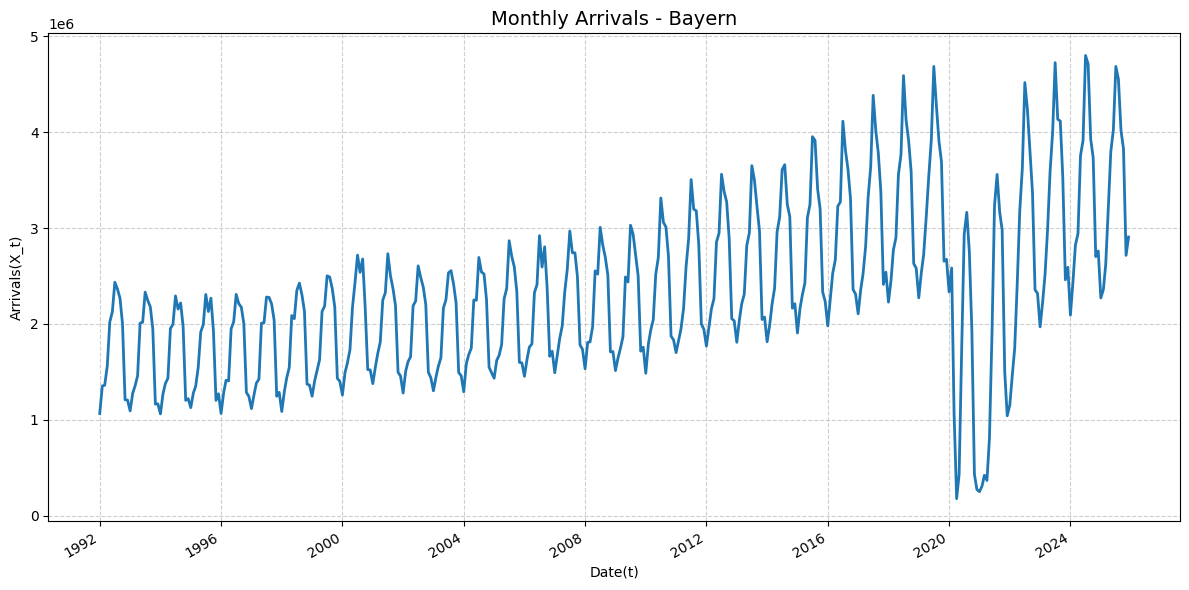

In [14]:
# Time series plot of X_t (enhanced version)

fig, ax = plt.subplots(figsize=(12, 6))

ax.plot(x_ts, linewidth=2)

ax.set_title(f"Monthly Arrivals - {state_name}", fontsize=14)
ax.set_xlabel("Date(t)")
ax.set_ylabel("Arrivals(X_t)")

ax.grid(True, linestyle="--", alpha=0.6)

fig.autofmt_xdate()
plt.tight_layout()
plt.show()

In [18]:
# Test the stationarity of X_t

# Perform KPSS test
kpss_test = KPSS(x_ts)
p_value = kpss_test.pvalue

# Print the results
print(f'p-value: {p_value:.3f}\n')

# Interpret the results
alpha = 0.05
if p_value >= alpha:
     print(f'The time series is stationary (fail to reject "H0: The time series is stationary" at a {100*alpha:.0f}% significance level).')
else: 
    print(f'The time series is not stationary (reject "H0: The time series is stationary" at a {100*alpha:.0f}% significance level).')

p-value: 0.000

The time series is not stationary (reject "H0: The time series is stationary" at a 5% significance level).


/var/folders/2_/4gjpcdfn1xv5133yqx63q_wc0000gn/T/ipykernel_70478/1503179283.py:4: DeprecationWarning: Lag selection has changed to use a data-dependent method. To use the old method that only depends on time, set lags=-1
  kpss_test = KPSS(x_ts)


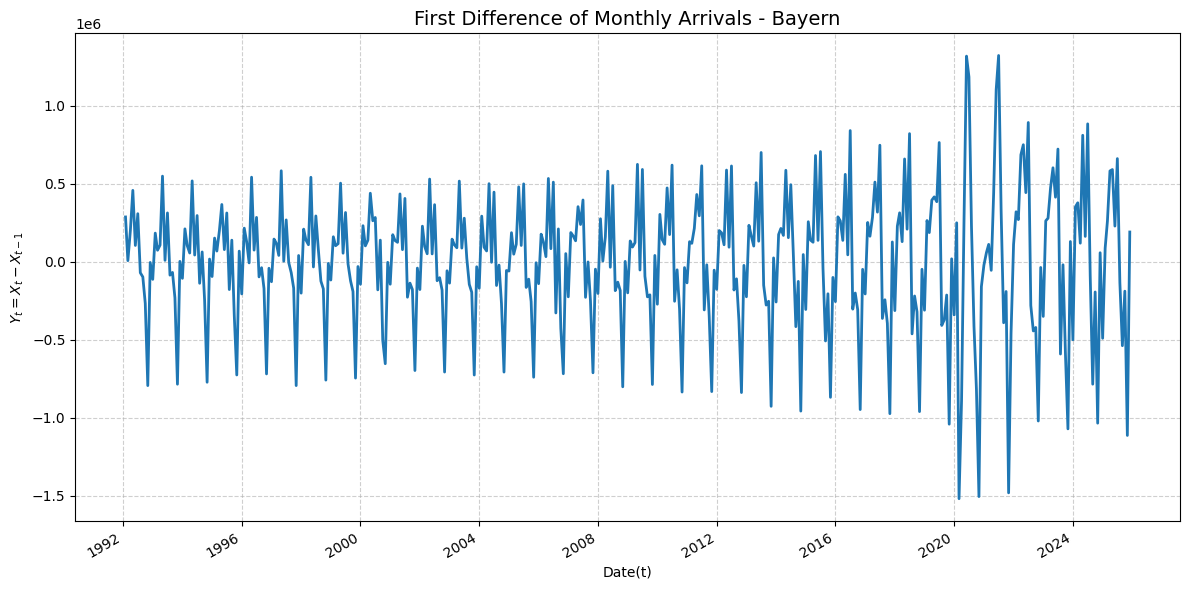

In [23]:
# Time series plot of Y_t := X_t - X_{t-1}

y_ts = x_ts.diff().dropna()

fig, ax = plt.subplots(figsize=(12, 6))

ax.plot(y_ts, linewidth=2)

ax.set_title(f"First Difference of Monthly Arrivals - {state_name}", fontsize=14)
ax.set_xlabel("Date(t)")
ax.set_ylabel(r"$Y_t = X_t - X_{t-1}$")

ax.grid(True, linestyle="--", alpha=0.6)

fig.autofmt_xdate()
plt.tight_layout()
plt.show()

In [24]:
# Test the stationarity of Y_t

# Perform KPSS test
kpss_test = KPSS(y_ts)
p_value = kpss_test.pvalue

# Print the results
print(f'p-value: {p_value:.3f}\n')

# Interpret the results
alpha = 0.05
if p_value >= alpha:
     print(f'The time series is stationary (fail to reject "H0: The time series is stationary" at a {100*alpha:.0f}% significance level).')
else: 
    print(f'The time series is not stationary (reject "H0: The time series is stationary" at a {100*alpha:.0f}% significance level).')


p-value: 0.998

The time series is stationary (fail to reject "H0: The time series is stationary" at a 5% significance level).


/var/folders/2_/4gjpcdfn1xv5133yqx63q_wc0000gn/T/ipykernel_70478/1163362364.py:4: DeprecationWarning: Lag selection has changed to use a data-dependent method. To use the old method that only depends on time, set lags=-1
  kpss_test = KPSS(y_ts)
